In [1]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
# Data source: IBM Telco Customer Churn Dataset
# Source: IBM GitHub
# Contains 7,043 customer records

df = pd.read_csv(
    "data/Telco-Customer-Churn.csv"
)

print("Number of customers:", len(df))
print(df.head())

Number of customers: 7043
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingM

In [3]:
# Convert TotalCharges to numbers
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [4]:
# Remove missing values
df = df.dropna(
    subset=["tenure", "MonthlyCharges", "TotalCharges"]
)

In [8]:
# Select features for clustering
features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

X = df[features]

In [9]:
# Scale the data
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [10]:
# Elbow Method
inertia = []

K = range(1, 6)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

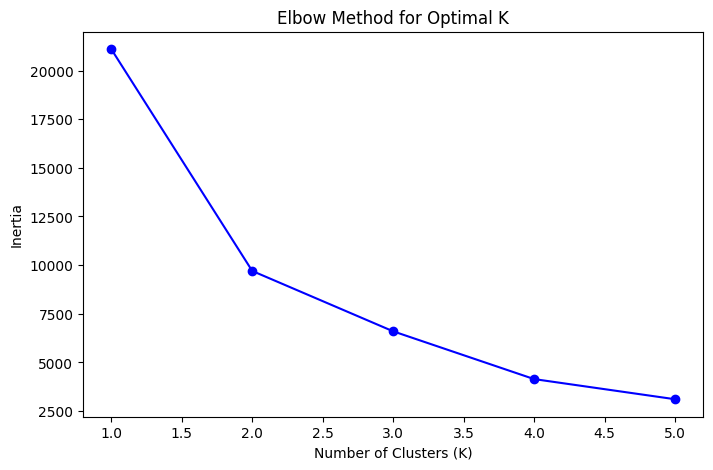

In [11]:
# Create elbow graph
plt.figure(figsize=(8, 5))

plt.plot(K, inertia, "bo-")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.savefig(
    "elbow_plot.png"
)

plt.show()

In [12]:
# Use 2 clusters
optimal_k = 2

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42
)

In [13]:
# Assign each customer to a cluster
df["cluster"] = kmeans.fit_predict(X_scaled)

In [14]:
# Show average characteristics of each cluster
cluster_summary = (
    df.groupby("cluster")[features]
    .mean()
    .round(2)
)

print("Cluster Characteristics:")

print(cluster_summary)

Cluster Characteristics:
         tenure  MonthlyCharges  TotalCharges
cluster                                      
0         56.87           89.76       5084.99
1         20.07           52.19        868.07


In [15]:
# Give a strategy for each cluster
for cluster in range(optimal_k):

    print(f"\nCluster {cluster} Strategy:")

    if cluster_summary.loc[cluster, "MonthlyCharges"] > 70:

        print(
            "High-paying customers: "
            "Offer loyalty rewards."
        )

    elif cluster_summary.loc[cluster, "tenure"] > 40:

        print(
            "Long-term customers: "
            "Offer renewal discounts."
        )

    else:

        print(
            "Newer customers: "
            "Send engagement offers."
        )


Cluster 0 Strategy:
High-paying customers: Offer loyalty rewards.

Cluster 1 Strategy:
Newer customers: Send engagement offers.


In [16]:
# Save customer clusters
df.to_csv(
    "customer_segments.csv",
    index=False
)

print("\nCustomer segments saved to customer_segments.csv")
print("Elbow plot saved to elbow_plot.png")


Customer segments saved to customer_segments.csv
Elbow plot saved to elbow_plot.png
